# Part 1: Image classification without deep learning: SVMs for MNIST
Heidi Klumpe

In [30]:
import numpy as np

# Data handling
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn
import sklearn.model_selection
import sklearn.svm
import sklearn.decomposition

## 1: Image analysis tasks

When analyzing images, we often want to do one of three things:
1. Image classification: Given a picture of one thing, identify what kind of thing it is.
2. Object detection or instance segementation: Given a picture, identify where particular objects are.
3. Semantic segmentation: For every pixel in an image, classify it (e.g., cell, not cell).

These are often the basis of further analysis (e.g., how many objects are there? what shapes do they have? what features did a model use to classify this image?). As discussed in lecture, one of the OrganoidTracker models is a type of object detection, as it outputs the position of nuclei in an image of many cells. The other two models do a kind of image classification, e.g., they predict the probability that a cell is dividing. For homework, you did image classification on the MNIST digits, to decide which digit was shown. 

Here, we will walk through a different approach for image classification, using the same MNIST dataset. This exercise will show us a few things:
* Common metrics for assessing the accuracy of an image analysis pipeline.
* How our choice of model affects model accuracy.
* How we can tune hyperparameters to improve  model accuracy, without changing its architecture.
* Whether we need deep learning for this task.

## 2: SVMs for classification
Support Vector Machines (SVMs) are kind of supervised machine learning used for classification. With the MNIST dataset, we have labeled example images that we can use to train a model that will predict, in other images, which of labeled examples it looks the most like. As you might imagine, this is general to many image types, including microscopy data.

The underlying idea for SVMs is that different examples will be close to each other in feature space, so a plane (or "model") that separates them can classify whether another example belongs to one group or the other. In the two-dimensional example below, there are two features ($x_1$ and $x_2$) and two labels (white or black). Models $H_2$ and $H_3$ correctly classify the two groups by separating them.

![image](/ai4nanobiology/week_4/image/svms-separating-groups.svg)

From wikipedia: https://en.wikipedia.org/wiki/Support_vector_machine#/media/File:Svm_separating_hyperplanes_(SVG).svg

#### Discussion 1
* Which model would have the lowest training error? Which model do you think is best? What approach might give the best separating line?

Even though $H_2$ and $H_3$ separate the data equally well, it seems possible that a new example might fall just across the classifier shown by $H_2$. In this way $H_3$ is better, as it doesn't unecessarily claim space for either label by sitting too close to the collection of points. This is the idea of maximizing the "margin" between our model and the data. We fit our SVM model as an optimization process that maximizes this margin.

In the following example we will:  
* **Load the training data** and briefly visualize it.  
* **Prepare the data for training** by checking for missing data and frequency of different examples.  
* **Train a _linear_ SVM**  
* **Train a _non-linear_ SVM**  

### 2.1: Load training data.

The MNIST dataset is a collection of written digits compiled by the US Census Bureau who wanted an automated way to digitize written digits. It was released in 1994. The data are already divided into a training set (60,000 examples) and a test set (10,000 examples). 

Load the training data as a `pandas` `DataFrame`.

In [8]:
df_digits = pd.read_csv('mnist_train.csv',header=None)

In [9]:
df_digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 359.3 MB


The `DataFrame` has a built in method showing what kind of object it is, how many examples there are, and what the data types (`dtypes`) are. Looks like it is just a bunch of 64-bit integers! Remember, **images are numbers**!

Using the `head` method shows a quick preview of our large datset.

In [10]:
df_digits.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The column labels are missing! We can add them back. It's not obvious from looking at this, but the first column is the "label" (which digit is in the image) and the following columns are the "image" (the 784 pixel intensities of the 28x28 pixel drawing).

In [11]:
col_labels = ['label'] + [f'pixel_{i:03d}' for i in range(784)]
df_digits.columns = col_labels
df_digits.head()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can now "look" at one example digit.

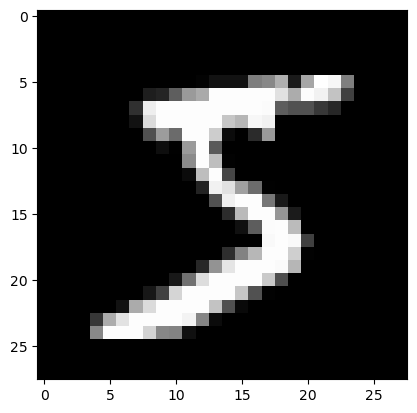

In [12]:
# Get the 0th row, all columns after the first
px_values_1d = df_digits.iloc[0,1:]

# Reshape as 2D iamge
px_values_2d = np.reshape(px_values_1d, (28,28))

# Plot the digit with gray colormap
plt.imshow(px_values_2d, cmap='gray')

### 2.2 Prepare data for training.

First, we check for **missing data.** Strange missing entries or the wrong datatype are not uncommon in large datasets and can generate cryptic errors later.

In [13]:
df_digits.isnull()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


One fast way I check that all entries in this are `False` is just to take the sum. `NumPy` automatically treats `False` as a 0 in this case.

In [14]:
np.sum(df_digits.isnull().values)

0

Although, technically we already knew there were no empty entries, since the`df_digits` DataFrame is all integers, and `NaN` is a float.

In [15]:
type(np.nan)

float

Next, we can check if our values make **biological sense.** Sepcifically, we expect only integers between 0 and 255 for our pixel values. We confirmed they are integers, but we can use another built-in method to check the range of values for each pixel.

In [16]:
df_description = df_digits.describe()
df_description

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


I'll use a plot to visually confirm that the minimum is never lower than 0, and the maximum is never higher than 255.

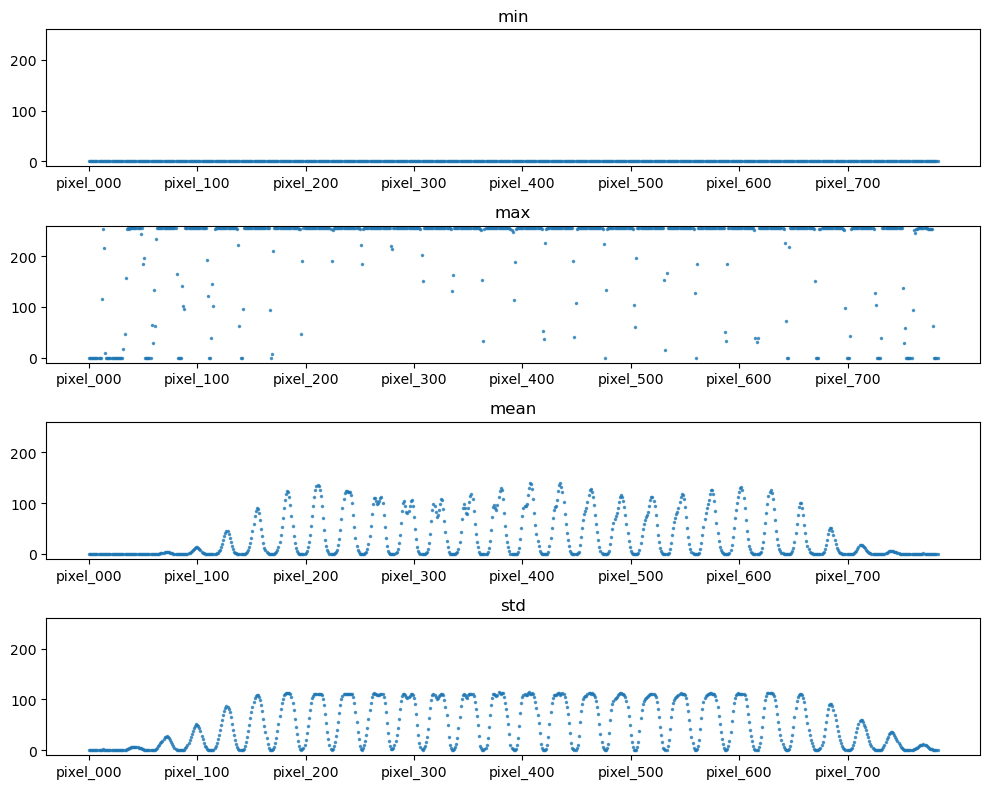

In [17]:
feature_list = ['min','max','mean','std']
fig, axes = plt.subplots(len(feature_list), 1, 
                         figsize=(10,2*len(feature_list)))

for f, feature in enumerate(feature_list):
    axes[f].plot(df_description.loc[feature][1:],
                 '.',
                markersize=3,
                alpha=0.7)
    axes[f].set_xticks(np.arange(0,800,100))
    axes[f].set_title(feature)
    axes[f].set_ylim([-10,260])
plt.tight_layout();

Note that each pixel ("feature") of the image has its own mean and standard deviation, which might indicate they have different scales, i.e., a value of 100 in one feature does not have the same magnitude as a value of 100 in another feature. However, we know here that all pixel values are on the same scale, but some pixels have more variation than others, especially in the middle. So you can rescale here to make the data more "regular," but it doesn't affect the result much.

We next check if we have **enough examples** of every label. Drawing our separating line could be challenging if there are few examples for a particular label.

In [18]:
df_digits.label.astype('category').value_counts()

label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

These are all fairly similar!

Lastly, we will split the data to **training and validation data** (confusingly, both are used for training). For both training and validation data, we have the features (pixel values, "X") from which we want to get the correct classification (what digit it is, "Y").

In [22]:
# Rescaling pixel values between 0 and 1 speeds up computation and improves numerical stability
pixel_values = df_digits.iloc[:,1:] / 255
labels = df_digits.iloc[:,0]

random_seed = 67

pixels_train, pixels_validate, labels_train, labels_validate = sklearn.model_selection.train_test_split(pixel_values, labels, 
                        train_size=0.8,
                        random_state=random_seed,
                        stratify=labels 
                        )

print(f"Training set: {pixels_train.shape}")
print(f"Validation set: {pixels_validate.shape}")

Training set: (48000, 784)
Validation set: (12000, 784)


### 2.3: Train a linear SVM.

First we try separating the data with a linear model. As we discussed above, these data might not be linearly separable so we will use a "soft-margin" approach, where we minimize not only (1) the inverse of the distance between the data and classifier (i.e., create a maximum margin) but also (2) the distance between all misclassified points and the model. 

However, we can choose the relative importance of these two quantities, with a parameter called $C$, which is the penalty for the misclassified points. Larger values of $C$ therefore behave like the "hard-margin" approach.

In [25]:
# Instantiate the SVM object with kernel and C
svm_linear = sklearn.svm.SVC(kernel='linear',
                            C=0.1,
                            random_state=random_seed)

# Train / fit the model
svm_linear.fit(pixels_train, labels_train)

SVC(C=0.1, kernel='linear', random_state=67)

### 2.4: Evaluate model results
We check the accuracy of our model with the validation dataset.

In [26]:
# Check accuracy of prediction on validation set
accuracy_linear = svm_linear.score(pixels_validate, labels_validate)
print(f"Linear SVM Accuracy: {accuracy_linear:.4f}")

Linear SVM Accuracy: 0.9452


The overall accuracy is high, which is already a good sign. To understand where the model fails, we can look at the confusion matrix.

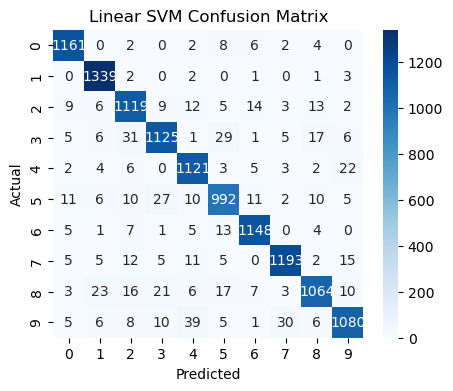

In [27]:
# Get the predicted labels for the validation set
labels_validate_linear_predict = svm_linear.predict(pixels_validate)

# Show the confusion matrix
plt.figure(figsize=(5,4))
cm = sklearn.metrics.confusion_matrix(labels_validate, labels_validate_linear_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Linear SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Note that the confusion matrix is not symmetric! The model is much more likely to think a 9 is a 4 than to think that a 4 is a 9.

In [28]:
# Compare true and predicted labels on the validation data.
print("Classification Report (Linear SVM):")
print(sklearn.metrics.classification_report(labels_validate, labels_validate_linear_predict))

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1185
           1       0.96      0.99      0.98      1348
           2       0.92      0.94      0.93      1192
           3       0.94      0.92      0.93      1226
           4       0.93      0.96      0.94      1168
           5       0.92      0.92      0.92      1084
           6       0.96      0.97      0.97      1184
           7       0.96      0.95      0.96      1253
           8       0.95      0.91      0.93      1170
           9       0.94      0.91      0.93      1190

    accuracy                           0.95     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.95      0.95      0.94     12000



We can get additional metrics from the classification report, which are also broken down by each label.

* `precision` is what fraction of the positive identifications are true positives (i.e., `tp / (tp + fp)`, where `tp` is true positive and `fp` is false positive), while `recall` is the what fraction of the data were correctly identified (i.e., `tp / (tp + fn)` where `fn` is false negative). High precision means few false positives, or that our labels are reliable. High recall means that most examples were identified. You can imagine that a model is very precise without having good recall (doesn't label everything, but what is does label is correct) or has good recall with poor precision (catches every example, but is also mislabeling other examples). These different kinds of errors could suggest different approaches for improving accuracy.
* The `f1-score` is a weighted mean of the precision and recall, essentially a way to summarize model performance in one number.
* The `support` is just the number of examples on which these numbers were calculated. The `macro avg` averages the precision and recall across all labels, while `weighted avg` gives an average weighted by the support (i.e., number of examples). 
* `accuracy`, as above, is just the number of correctly identified examples over the number of examples.

For many image analysis approaches, you will see them reporting precision, recall, and F1 score to summarize how well the model performs.

#### Discussion 2
* How many hyperplanes (i.e. "lines") are necessary to generate a model that classifies the MNIST digits?
* Is your model good?
* What is the difference between training, validation, and test data? Why are these distinctions necessary or useful?

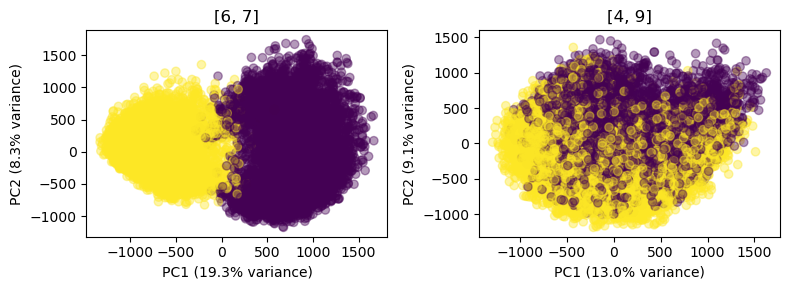

In [31]:
pairs = [[6,7],[4,9]]
fig, axes = plt.subplots(1,len(pairs), figsize=(8, 3))

for p, pair in enumerate(pairs):
    df_subset = df_digits.loc[df_digits.label.isin(pair)]

    pca = sklearn.decomposition.PCA(n_components=2)
    X_pca = pca.fit_transform(df_subset[df_subset.columns[1:]])
    
    ax = axes[p]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                         alpha=0.4,
                         c=df_subset['label'], 
                         cmap='viridis')
    # plt.colorbar(scatter, ax=ax, label='class')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title(pair)

plt.tight_layout()
plt.show()

### 2.5: Train a nonlinear SVM - use the RBF kernel.

Our model may be inaccurate because no linear model exists that can perfectly separate all digits. For example, it makes sense that 9 often looks like a 4.

Rather than simply allowing misclassification with $C$, we might just prefer a more accurate model. There may exist a nonlinear model that can separate our data, which we can find by using a different "kernel," or a transformation of the data such that they are now linearly separable.

![ai4nanobiology/week_4/image/nonlinear-kernel.png](ai4nanobiology/week_4/image/nonlinear-kernel.png)

Image from wikipedia: https://en.wikipedia.org/wiki/Support_vector_machine#/media/File:Kernel_Machine.svg

We will use the Radial Basis Function (RBF) kernel. This is equivalent to mapping the data to an infinitely dimensional space to identify possible separations. Other kernels require us to be quite explicit about how we want to transform the data (e.g, a specific polynomial power), so the RBF can be conveniently general.

As is a common theme in machine learning and model fitting, this more complex model will require more parameters and will take longer to train. For the RBF kernel, we introduce a new parameter $\gamma$. This is a feature of RBF that describes how close in space points must be to be considered similar. At high $\gamma$, only very close points are considered similar, allowing boundaries to be tightly drawn around individual datapoints, and vice versa if $\gamma$ is large. Luckily, `sklearn` has a way to automatically compute the "best" value of $\gamma$, when you specify its value as `scale`. Otherwise, it is a float.

In [32]:
# Instantiate the SVM object with kernel and C
svm_rbf = sklearn.svm.SVC(kernel='rbf',
                            C=0.1,
                             gamma='scale',
                            random_state=random_seed)

# Train / fit the model
svm_rbf.fit(pixels_train, labels_train)

SVC(C=0.1, random_state=67)

In [33]:
accuracy_rbf = svm_rbf.score(pixels_validate, labels_validate)
print(f"RBF SVM Accuracy: {accuracy_rbf:.4f}")

RBF SVM Accuracy: 0.9574


We can also plot the confusion matrix and look at the classification report.

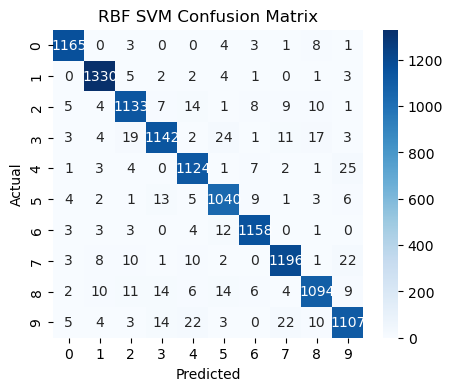

In [34]:
# Get the predicted labels for the validation set
labels_validate_rbf_predict = svm_rbf.predict(pixels_validate)

# Show the confusion Matrix
plt.figure(figsize=(5, 4))
cm = sklearn.metrics.confusion_matrix(labels_validate, labels_validate_rbf_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('RBF SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
# Compare true and predicted labels on the validation data.
print("Classification Report (RBF SVM):")
print(sklearn.metrics.classification_report(labels_validate, labels_validate_rbf_predict))

Classification Report (RBF SVM):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1185
           1       0.97      0.99      0.98      1348
           2       0.95      0.95      0.95      1192
           3       0.96      0.93      0.94      1226
           4       0.95      0.96      0.95      1168
           5       0.94      0.96      0.95      1084
           6       0.97      0.98      0.97      1184
           7       0.96      0.95      0.96      1253
           8       0.95      0.94      0.94      1170
           9       0.94      0.93      0.94      1190

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



Our model was already quite good, but we have indeed improved the accuracy a bit, from 0.95 to 0.96. 
#### Discussion 3
* Do you think it is possible to improve model accuracy even more? (i.e., do you think the limit is a problem with the data themselves, or how we are building our models?)

## 3: Improve model accuracy with hyperparameter tuning

We have already seen that choosing a different model can improve fitting (i.e., prediction). But we also know that we are solving an optimization problem, where $C$ and $\gamma$ are part of the expression we are optimizing. There may be values of those hyperparameters that could produce _even better_ models.

Here is where using the validation set is valuable. We can train a bunch of different models on the same training data, but then pick our favorite model by seeing which does best on the validation data. Then we report the final model accuracy by checking its performance on the test set, which has truly never been part of the model training.

### 3.1: Hyperparameter grid search on data subset
It is challenging to intuitively guess what the best values for $C$ and $\gamma$ will be. Therefore, we can empirically find them by just trying many combinations in a grid search. We will try all possible combinations of three different values for each of our hyperparameters: 3 for $C$ and 3 for $\gamma$. 

Luckily, `sklearn` automates this grid search and makes it even more robust with cross validation. For each hyperparameter set, it fits the data a few different times to understand its average performance. For `cv=3`, the data is split into thirds. It then fits the data three times, each time leaving out one of those thirds and training on the other two. The performance is then the average of the those three models' performance.

Since this means we will train 27 (3\*3\*3) models, let's reduce the training set size to speed things up.

In [36]:
train_size = 0.1 # Percentage of data to include for grid search

pixels_train_cv, pixels_validate_cv, labels_train_cv, labels_validate_cv = sklearn.model_selection.train_test_split(pixel_values, labels, 
                        train_size=train_size,
                        random_state=random_seed,
                        stratify=labels 
                        )

In [37]:
parameters = {'C': [0.1, 1, 10],
             'gamma': [0.01, 0.1, 0.5]}

# Instantiate the model
svc_rbf_grid_search = sklearn.svm.SVC(kernel='rbf', random_state=random_seed)

# Instantiate the grid search, using the model and kwargs for how to do grid search
grid_search = sklearn.model_selection.GridSearchCV(svc_rbf_grid_search,
                            parameters,
                            cv=3,
                            n_jobs=-1,
                            return_train_score=True)

# Run the grid search
grid_search.fit(pixels_train_cv, labels_train_cv);

In [38]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'C': 10, 'gamma': 0.01}
Best CV accuracy: 0.9512


In [39]:
cv_results = pd.DataFrame(grid_search.cv_results_)

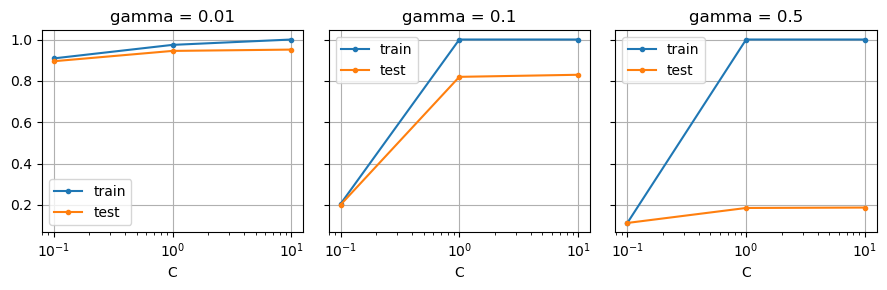

In [40]:
n_gamma = len(parameters['gamma'])
fig, axes = plt.subplots(1,n_gamma, 
                         sharey=True,
                        figsize=(3*n_gamma,3))

for g, param_gamma in enumerate(parameters['gamma']):
    df_g = cv_results.loc[cv_results['param_gamma']==param_gamma]

    for dataset in ['train','test']:
        axes[g].plot(df_g['param_C'],
                 df_g[f'mean_{dataset}_score'],
                 '.-',
                 label=dataset)

    axes[g].set_xscale('log')
    axes[g].set_xlabel('C')
    axes[g].set_title(f'gamma = {param_gamma}')
    axes[g].legend()
    axes[g].grid(True)
    
plt.tight_layout()
        

Here we see that model performance is always worse in the validation set (called "test" data in `sklearn`'s report), likely because the model hasn't been explicitly trained on those examples. 

### 3.2: Train full dataset with best-possible hyperparameters

Our grid search showed us that a value of 0.1 for $C$ was actually too little penalty for misclassified points, and that we can actually do better. We therefore repeat our training with our best hyperparameters.

In [41]:
# Instantiate the SVM object with kernel and C
svm_rbf_besthp = sklearn.svm.SVC(kernel='rbf',
                            C=10,
                             gamma='scale',
                            random_state=random_seed)

# Train / fit the model
svm_rbf_besthp.fit(pixels_train, labels_train)

SVC(C=10, random_state=67)

In [43]:
accuracy_rbf_besthp = svm_rbf_besthp.score(pixels_validate, labels_validate)
print(f"RBF SVM Accuracy: {accuracy_rbf_besthp:.4f}")

RBF SVM Accuracy: 0.9858


This is our biggest jump in accuracy yet, with almost 99% accuracy! Note that this is higher than the accuracy we got in our parameter screen, but this is because the parameter screen trained only on a subset of the data.

Such improvements from hyperparameter tuning may not always be the case, and you may find limits in model accuracy for other reasons, such as training data being limited or the data not being classifiable because there is genuine overlap between exmaples. Also, very small improvements in accuracy could still be valuable, depending on the application. For example, if we were classifying a lot of digits every day, maybe it would be valuable to improve accuracy a fraction of a percent. 

#### Discussion 4
* Looking only at the "training" error, which models are best? 
* Considering also the validation error, when does the model generalize the best? Can you explain this in terms of the parameters $C$ and/or $\gamma$?

## Future exploration

* Run the grid search on parameter C - is it possible to make the linear model perform as well as RBF?
* Check out the SVM weights of your linear model to see if you can interpret how the model distinguishes digits from each other.
* Repeat the grid search, but with the full dataset and/or the full training set. Do you get the same result for the best hyper parameters?